# 4. Will it touch the level? First-passage maths from scratch

**What this notebook answers:** prediction markets list questions like *"Will Bitcoin hit $110,000
this month?"*. How do we put a probability on that, from first principles, and why is it **not**
the same as "will Bitcoin be above $110,000 at the end of the month?"

Everything here is checked two ways: by a formula, and by brute-force simulation of thousands of
possible futures. When the two agree we trust the formula.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _style as st
from pmq.crypto import barrier, paths

st.setup()
DAY = 1 / 365
rng = np.random.default_rng(11)

## 4.1 The model: a random walk in the log-price

The workhorse model of a price is **geometric Brownian motion**. In plain English: each instant
the *logarithm* of the price takes a small random step. Working with the log means moves are
proportional (a 1% move is a 1% move whether the price is $100 or $100,000) and the price can never go negative.

Three numbers describe it:

* **volatility** $\sigma$ (annualised): how big the random steps are. Crypto is high: 40–100%.
* **drift** $\mu$: the average direction. We usually set it near zero over short horizons, because the noise dwarfs it.
* **time** $T$ in years (crypto trades 24/7, so 1 day = 1/365).

A barrier contract asks about the *path*, not just the destination. Here are six simulated
weeks of a coin with 80% volatility, with a barrier 10% above the start:

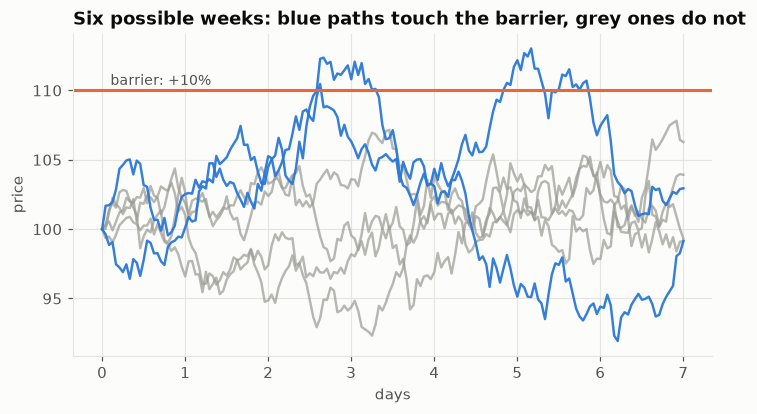

In [2]:
n_steps, T, sigma = 168, 7 * DAY, 0.8                       # one week, hourly steps
inc = paths.gbm_increments(6, n_steps, T, sigma, 0.0, rng)
prices = 100 * np.exp(np.cumsum(inc.dx, axis=1))
prices = np.column_stack([np.full(6, 100.0), prices])
hours = np.arange(n_steps + 1) / 24

fig, ax = plt.subplots()
for p in prices:
    touched = p.max() >= 110
    ax.plot(hours, p, color=st.BLUE if touched else st.GREY, lw=1.6, alpha=0.95 if touched else 0.7)
ax.axhline(110, color=st.ORANGE, lw=2)
ax.annotate("barrier: +10%", (0.1, 110.4), color=st.INK_SOFT, fontsize=9)
ax.set_xlabel("days"); ax.set_ylabel("price"); ax.set_title("Six possible weeks: blue paths touch the barrier, grey ones do not")
plt.show()

## 4.2 The reflection principle: why "touch" is roughly double "finish above"

Suppose the log-price has **no drift**. Take any path that touches the barrier and then wanders back
down to finish *below* it. Now flip that path upside-down around the barrier from the moment
it first touched. You get a different path, equally likely (random steps are symmetric), that finishes *above* the barrier.

That gives a one-to-one match:

* every path that **finishes above** the barrier must have touched it, and
* every path that touched it and **finishes below** has a mirror twin that finishes above.

So paths that touch = (paths that finish above) + (their mirror twins) = **2 × (paths that finish above)**.

$$P(\text{touch}) = 2\,P(S_T > K) = 2\,\Phi\!\left(-\frac{b}{\sigma\sqrt T}\right), \qquad b=\ln(K/S_0)$$

where $\Phi$ is the standard bell-curve probability. Here is one path and its mirror twin:

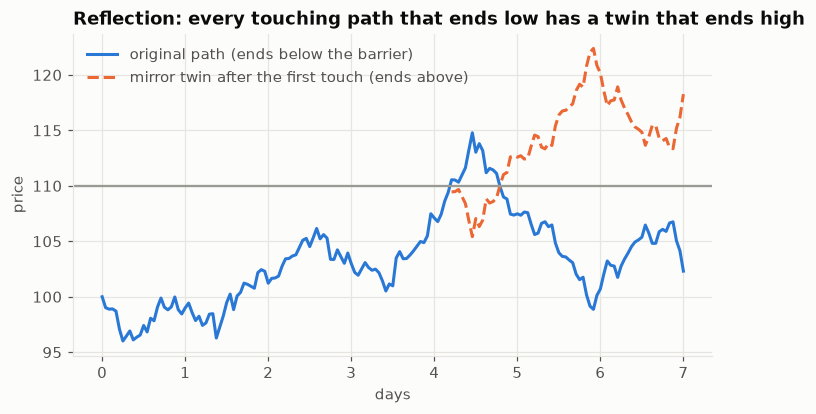

In [3]:
b = np.log(1.10)
while True:                                                  # find a path that touches, then ends below
    inc = paths.gbm_increments(1, n_steps, T, sigma, 0.5 * sigma**2, rng)
    x = np.concatenate([[0.0], np.cumsum(inc.dx[0])])
    hit = np.argmax(x >= b) if (x >= b).any() else None
    if hit is not None and x[-1] < b - 0.02:
        break
mirror = x.copy(); mirror[hit:] = 2 * b - x[hit:]
h = np.arange(n_steps + 1) / 24
fig, ax = plt.subplots()
ax.plot(h, 100 * np.exp(x), color=st.BLUE, label="original path (ends below the barrier)")
ax.plot(h[hit:], 100 * np.exp(mirror[hit:]), color=st.ORANGE, ls="--", label="mirror twin after the first touch (ends above)")
ax.axhline(110, color=st.GREY, lw=1.5)
ax.set_xlabel("days"); ax.set_ylabel("price"); ax.set_title("Reflection: every touching path that ends low has a twin that ends high")
ax.legend(loc="upper left")
plt.show()

## 4.3 With drift: the full formula

Real prices drift. Let $\nu = \mu - \sigma^2/2$ be the drift of the *log*-price. The mirror argument then needs a correction factor, giving

$$P(\text{touch}) \;=\; \Phi\!\left(\frac{-b + \nu T}{\sigma\sqrt T}\right) \;+\; e^{2\nu b/\sigma^2}\,\Phi\!\left(\frac{-b - \nu T}{\sigma\sqrt T}\right).$$

The first term is the chance of finishing above. The second is the mirror-twin term, which
grows with a favourable drift (you are more likely to have touched *and come back*) and shrinks against it.
The code is `pmq.crypto.barrier.touch_probability`. **Check it against simulation:** 200,000 simulated weeks, each with a fine grid and the bridge correction described in 4.5.

In [4]:
sigma, T = 0.8, 7 * DAY
rows = []
for pct in (3, 5, 10, 15, 25):
    k = 100 * (1 + pct / 100)
    closed = float(barrier.touch_probability(100.0, k, sigma, T))
    inc = paths.gbm_increments(200_000, 48, T, sigma, 0.0, rng)
    p, se = paths.mc_touch_probability(inc, np.log(k / 100))
    rows.append({"barrier": f"+{pct}%", "closed form": closed, "simulation": p, "sim. std error": se,
                 "gap in std errors": (p - closed) / se})
pd.DataFrame(rows).set_index("barrier").round(4)

,closed form,simulation,sim. std error,gap in std errors
barrier,,,,
+3%,0.7778,0.7790,0.0009,1.3497
+5%,0.6435,0.6435,0.0010,0.0158
+10%,0.3712,0.3698,0.0011,-1.3676
+15%,0.1930,0.1920,0.0009,-1.0999
+25%,0.0393,0.0392,0.0004,-0.3119


The gap is within about two standard errors in every row, which is what sampling noise looks like: **the formula and the simulation agree.**

## 4.4 "Touch" versus "finish above": the ratio is not always 2

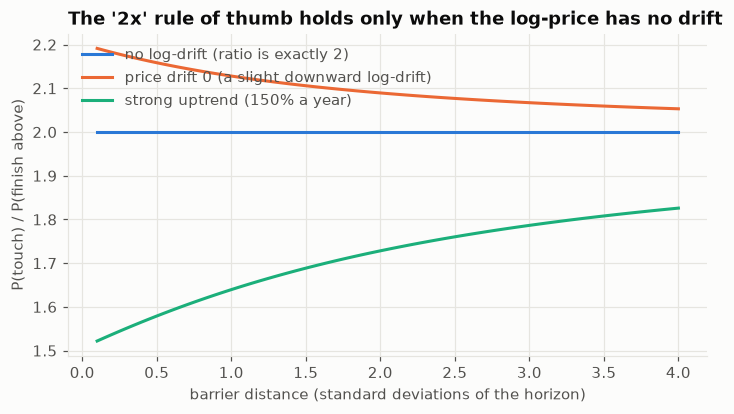

In [5]:
z = np.linspace(0.1, 4.0, 80)                                # barrier distance in standard deviations
sigma, T = 0.8, 30 * DAY
k = 100 * np.exp(z * sigma * np.sqrt(T))
fig, ax = plt.subplots()
for mu, name, colour in [(0.5 * sigma**2, "no log-drift (ratio is exactly 2)", st.BLUE),
                         (0.0, "price drift 0 (a slight downward log-drift)", st.ORANGE),
                         (1.5, "strong uptrend (150% a year)", st.AQUA)]:
    ratio = barrier.touch_probability(100.0, k, sigma, T, mu) / barrier.terminal_probability(100.0, k, sigma, T, mu)
    ax.plot(z, ratio, color=colour, label=name)
ax.set_xlabel("barrier distance (standard deviations of the horizon)"); ax.set_ylabel("P(touch) / P(finish above)")
ax.set_title("The '2x' rule of thumb holds only when the log-price has no drift"); ax.legend(loc="upper left")
plt.show()

The rule of thumb is exactly 2 only with zero log-drift. In an uptrend the ratio is lower (finishing
above is already likely, so touching adds little on top); with a slight downward log-drift it is a
little higher. The gap from 2 is largest close to the money and fades far out, where the barrier
is reached mainly through one big early move that the drift barely changes. **A model that simply doubles a
"finish above" price is therefore off by a few percent**, and the backtest in notebook 8 measures what that costs.

## 4.5 Real venues do not watch continuously

The formula assumes the barrier is checked at every instant. Venues actually look at
**1-minute candle highs and lows**. A path can slip through the barrier *between* checks and never be seen,
so a discretely watched barrier is a little harder to hit. Broadie, Glasserman and Kou (1997) showed the effect is almost exactly that of
**moving the barrier away by a factor $e^{0.5826\,\sigma\sqrt{\Delta t}}$**, where $\Delta t$ is the gap between checks. Let's test that claim.

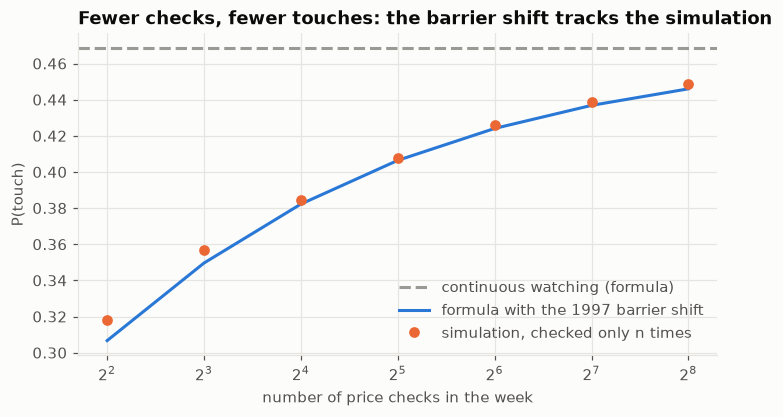

In [6]:
sigma, T, k = 0.8, 7 * DAY, 108.0
continuous = float(barrier.touch_probability(100.0, k, sigma, T))
checks = np.array([4, 8, 16, 32, 64, 128, 256])
mc, bgk = [], []
for n in checks:
    dx = paths.gbm_increments(150_000, int(n), T, sigma, 0.0, rng).dx
    x = np.cumsum(dx, axis=1)
    mc.append(np.mean(x.max(axis=1) >= np.log(k / 100)))    # discrete: only the sampled points are seen
    bgk.append(float(barrier.touch_probability(100.0, k, sigma, T, 0.0, monitor_dt_years=T / n)))

fig, ax = plt.subplots()
ax.axhline(continuous, color=st.GREY, ls="--", label="continuous watching (formula)")
ax.plot(checks, bgk, color=st.BLUE, label="formula with the 1997 barrier shift")
ax.plot(checks, mc, "o", color=st.ORANGE, label="simulation, checked only n times")
ax.set_xscale("log", base=2); ax.set_xlabel("number of price checks in the week"); ax.set_ylabel("P(touch)")
ax.set_title("Fewer checks, fewer touches: the barrier shift tracks the simulation"); ax.legend(loc="lower right")
plt.show()

The shifted formula follows the simulation closely. With 1-minute checks over a week (10,080
checks) the correction is small but real, worth a few tenths of a percentage point near the
barrier. (The shift is an approximation and is least accurate with only a handful of checks, as the left of the chart shows.) The pricing code applies it by default for venue-style contracts (`monitor_dt_years=MINUTE_YEARS`).

## 4.6 The clock: probability decays as time runs out

Inside a contract's life the probability updates as the price moves and time passes. Because the
process has no memory (the Markov property), the *only* things that matter are today's price, the
highest price so far, and the time left. If the running high has already reached the barrier,
the answer is simply 1. Otherwise price it from today's price with the remaining time:

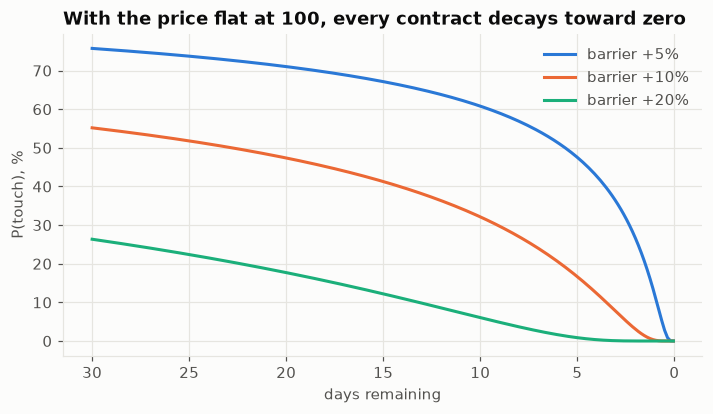

In [7]:
days_left = np.linspace(30, 0.05, 200)
fig, ax = plt.subplots()
for pct, colour in [(5, st.BLUE), (10, st.ORANGE), (20, st.AQUA)]:
    p = barrier.touch_probability(100.0, 100 * (1 + pct / 100), 0.6, days_left * DAY)
    ax.plot(days_left, p * 100, color=colour, label=f"barrier +{pct}%")
ax.invert_xaxis(); ax.set_xlabel("days remaining"); ax.set_ylabel("P(touch), %")
ax.set_title("With the price flat at 100, every contract decays toward zero"); ax.legend()
plt.show()

## 4.7 "Hit X or Y first"

Polymarket also lists contracts like *"Will Bitcoin hit $80k or $100k first?"*: two barriers, no time limit.
This is the **gambler's ruin** problem. Find a quantity that is a fair game as the price moves (a
*scale function*); for a driftless log-price it is just the log-price itself. Then the probability of
exiting through the top is how far the start sits between the barriers **on that scale**:

$$P(\text{hit upper first}) = \frac{\ln S_0 - \ln L}{\ln U - \ln L} \quad (\text{no drift}).$$

With drift $\nu$ the scale function becomes $s(x) = 1 - e^{-2\nu x/\sigma^2}$, and the same ratio applies.

In [8]:
def simulate_first_exit(s0, lo, hi, sigma, mu, n=3000, dt=1 / (365 * 24 * 4)):
    nu = mu - 0.5 * sigma**2
    x = np.zeros(n); alive = np.ones(n, bool); up = np.zeros(n, bool)
    a, b = np.log(lo / s0), np.log(hi / s0)
    while alive.any():
        x[alive] += nu * dt + sigma * np.sqrt(dt) * rng.standard_normal(alive.sum())
        up |= alive & (x >= b); alive &= (x > a) & (x < b)
    return up.mean(), np.sqrt(up.mean() * (1 - up.mean()) / n)

rows = []
for lo, hi, mu in [(90, 110, 0.0), (90, 120, 0.0), (80, 125, 0.0), (90, 110, 1.0)]:
    exact = barrier.first_exit_upper_probability(100.0, lo, hi, 0.9, mu)
    sim, se = simulate_first_exit(100.0, lo, hi, 0.9, mu)
    rows.append({"lower": lo, "upper": hi, "price drift": mu, "formula": exact, "simulation": sim, "std error": se})
pd.DataFrame(rows).round(3)

,lower,upper,price drift,formula,simulation,std error
0,90,110,0.0,0.500,0.504,0.009
1,90,120,0.0,0.333,0.339,0.009
2,80,125,0.0,0.444,0.444,0.009
3,90,110,1.0,0.562,0.572,0.009


## Recap

* A touch contract is a question about the **highest (or lowest) point** of the path.
* The **reflection principle** turns it into a bell-curve calculation; with zero log-drift it is exactly **2 × "finish above"**, and drift breaks that.
* Venues check 1-minute candles, so we shift the barrier slightly (**Broadie–Glasserman–Kou**).
* The probability depends only on today's price, the running extreme and the time left, so it can be **updated live**.
* "First of X or Y" is the **gambler's-ruin** ratio on the scale function.
* Every formula here is tested against simulation in `tests/test_barrier.py` and `tests/test_paths.py`.

**Next:** the formulas take a volatility as input, and that is the number that decides everything. Notebook 5 estimates it from 92 million Bitcoin trades.